<a href="https://colab.research.google.com/github/Dheeraj12-stack/capgemini/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://drive.google.com/file/d/1_U2a0labAmIF82IjaVPp4GAAnWEBdzT8/view?usp=drive_link

1. Import Libraries


In [ ]:
import numpy as np
import pandas as pd

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

2. Load Dataset

In [ ]:
df = pd.read_csv("/content/house_pricing_dataset.csv")

3. Basic Exploration



In [ ]:
print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

   HouseID Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1  Houston         5          2         809  330553
1        2  Houston         4          3        1318  467638
2        3  Phoenix         2          4        3089  719266
3        4  Chicago         5          4        1289  505649
4        5  Houston         2          4        4978  732338
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   HouseID     1000 non-null   int64 
 1   Location    1000 non-null   object
 2   Bedrooms    1000 non-null   int64 
 3   Bathrooms   1000 non-null   int64 
 4   SquareFeet  1000 non-null   int64 
 5   Price       1000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 47.0+ KB
None
           HouseID     Bedrooms    Bathrooms   SquareFeet         Price
count  1000.000000  1000.000000  1000.000000  1000.000000  1.000000e+03
mean    5

4. Drop Unnecessary Column

5. Encode Categorical Column

In [ ]:
le = LabelEncoder()

df["Location"] = le.fit_transform(df["Location"])
print(df.head())


   HouseID  Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1         1         5          2         809  330553
1        2         1         4          3        1318  467638
2        3         4         2          4        3089  719266
3        4         0         5          4        1289  505649
4        5         1         2          4        4978  732338


6. Define Features and Target


In [ ]:
X = df.drop("Price", axis=1)

y = df["Price"]
print(X)

     HouseID  Location  Bedrooms  Bathrooms  SquareFeet
0          1         1         5          2         809
1          2         1         4          3        1318
2          3         4         2          4        3089
3          4         0         5          4        1289
4          5         1         2          4        4978
..       ...       ...       ...        ...         ...
995      996         3         1          3        4679
996      997         0         2          4        2346
997      998         3         2          1        3812
998      999         4         2          3        1533
999     1000         3         1          1        4116

[1000 rows x 5 columns]


7. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

  8. Train Model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

9. Make Predictions

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[1027617.9572424   503949.70215013  595570.10090638  722026.976194
  343715.74073304  748963.03988453  675595.69528549  823011.60919821
  843134.2107717   997194.62235588  741399.99925302  870381.77189424
  733249.3180752  1061734.7234407   631718.67471771  653817.68665371
  831617.837384    480691.85769002  636751.19420593  811560.24645789
  602766.57077997  350342.99706638  594784.19142197  666431.95988533
  592641.95964814  435080.99892199  487314.42601615  743798.748163
  836535.43593138  324216.64568514  673894.00572417  748875.79449434
  450009.80484107  929691.81873459  857487.76475079  595748.83036367
  765206.16817816  856436.59000963  504576.25150412  662828.25736441
  439283.64730034  993903.99023256  477244.46542075 1025808.61966274
 1009896.43856985  406257.96861043  647812.4796212   389327.03876674
  286500.12741991  725332.98222127  869966.25130002 1036959.66023149
  933198.7837213  1014353.32180898  652462.04571819  462648.94533326
  631903.63177963 1016244.95082295  57

11. Visualization

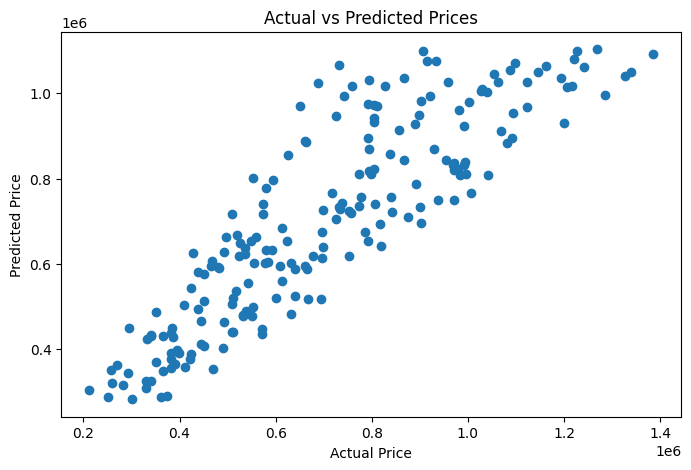

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

10. Evaluate Model
MAE

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 104481.54929459932


RMSE

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 129857.21068213946


R² Score

In [ ]:
new_house = [[0, 2, 3, 2, 1800]]  # Added a placeholder for HouseID (0)

prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 476503.99992548267


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.7672814566907895
